- save this function and call it 
- run everything with mutiple random states 

In [1]:
# from pathlib import Path

# import numpy as np
# from Functions import remove_baseline_filter, split_participants_by_pid, preprocess_group, stack_by_sorted_keys ,  WindowDataset, CNN1D, prepare_mouth_data_loaders , train_model_with_loaders

# # ----------------------------
# # PARAMETERS (stay in notebook)
# # ----------------------------
# folder = Path(r"C:\Users\saber\thesis_second_try\data\Rest\Respiration_ECG_Raw")

# FS_IN = 1000
# FS_OUT = 60
# WIN_LEN = 2048
# STRIDE = WIN_LEN  # non-overlap

# # KEEP_SIGNALS = ["ECG_mV", "Fingerpulse", "Cannula", "Thermopod"]
# KEEP_SIGNALS = ["ECG_mV", "Fingerpulse"]

# SCALE = {
#     "ECG_mV": 1000.0,      # V -> mV
#     "Fingerpulse": 10.0,
#     "Cannula": 10.0,
#     "Thermopod": 1.0
# }

# # ----------------------------
# # RUN
# # ----------------------------
# SOS = remove_baseline_filter(FS_IN)

# mat_files = sorted(folder.glob("*.mat"))
# participant_files = [f for f in mat_files if f.name.startswith("resting_state_participant_")]

# print("Total .mat files:", len(mat_files))
# print("Participant files:", len(participant_files))

# nose_files, mouth_files, skipped = split_participants_by_pid(participant_files)

# print("Nose files :", len(nose_files))
# print("Mouth files:", len(mouth_files))
# print("Skipped    :", len(skipped))

# nose_dict, nose_failed = preprocess_group(
#     nose_files,
#     fs_in=FS_IN, fs_out=FS_OUT, win_len=WIN_LEN, stride=STRIDE,
#     keep_signals=KEEP_SIGNALS, scale=SCALE, sos=SOS
# )

# mouth_dict, mouth_failed = preprocess_group(
#     mouth_files,
#     fs_in=FS_IN, fs_out=FS_OUT, win_len=WIN_LEN, stride=STRIDE,
#     keep_signals=KEEP_SIGNALS, scale=SCALE, sos=SOS
# )

# failed = [("nose",) + x for x in nose_failed] + [("mouth",) + x for x in mouth_failed]

# print("Processed nose :", len(nose_dict))
# print("Processed mouth:", len(mouth_dict))
# print("Failed:", len(failed))

# if len(nose_dict) > 0:
#     X_nose, nose_keys = stack_by_sorted_keys(nose_dict)
#     print("X_nose shape:", X_nose.shape)

# if len(mouth_dict) > 0:
#     X_mouth, mouth_keys = stack_by_sorted_keys(mouth_dict)
#     print("X_mouth shape:", X_mouth.shape)


In [2]:
from pathlib import Path
import re

import numpy as np
import scipy.signal as sgn
from scipy.io import loadmat

folder = Path(r"C:\Users\saber\thesis_second_try\data\Rest\Respiration_ECG_Raw")

FS_IN = 1000
FS_OUT = 60
WIN_LEN = 2048
STRIDE = WIN_LEN  # non-overlap

SIGNAL_ORDER = ["ECG_mV", "Fingerpulse", "Cannula", "Thermopod"]
SIGNAL_ORDER = ["ECG_mV", "Fingerpulse", "Cannula", "Thermopod"]

# KEEP_SIGNALS = ["ECG_mV", "Fingerpulse", "Cannula", "Thermopod"]
# KEEP_SIGNALS = ["ECG_mV", "Fingerpulse"]

# --- experiment: keep only these signals (channels) ---
KEEP_SIGNALS = ["ECG_mV", "Cannula"]  # ECG + Cannula only

# Optimal scales for each
SCALE = {
    "ECG_mV": 1000.0,      # V -> mV
    "Fingerpulse": 10.0,
    "Cannula": 10.0,
    "Thermopod": 1.0
}

# Baseline Filter function
# https://github.com/antonior92/ecg-preprocessing/blob/64a2715b15ea5ee1a482e5319d2cbaf45edef6f4/ecgprep/preprocess.py#L30C1-L40C15
def remove_baseline_filter(sample_rate: int):
    fc = 0.8
    fst = 0.2
    rp = 0.5
    rs = 40

    wn = fc / (sample_rate / 2)
    wst = fst / (sample_rate / 2)
    order, _ = sgn.ellipord(wn, wst, rp, rs)
    sos = sgn.iirfilter(order, wn, rp, rs, btype="high", ftype="ellip", output="sos")
    return sos

SOS = remove_baseline_filter(FS_IN)

# One file -> (n_windows, len(KEEP_SIGNALS), WIN_LEN)
def preprocess_one_file(mat_path: Path) -> np.ndarray:
    m = loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    rs = m["resting_state"]

    # baseline removal (filter at original sampling rate)
    ecg_f   = sgn.sosfiltfilt(SOS, rs.ECG)
    fp_f    = sgn.sosfiltfilt(SOS, rs.Fingerpulse)
    can_f   = sgn.sosfiltfilt(SOS, rs.Cannula)
    therm_f = sgn.sosfiltfilt(SOS, rs.Thermopod)

    # resample to 60 Hz
    ecg_60   = sgn.resample_poly(ecg_f,   up=FS_OUT, down=FS_IN)
    fp_60    = sgn.resample_poly(fp_f,    up=FS_OUT, down=FS_IN)
    can_60   = sgn.resample_poly(can_f,   up=FS_OUT, down=FS_IN)
    therm_60 = sgn.resample_poly(therm_f, up=FS_OUT, down=FS_IN)

    # scale
    ecg_60   = ecg_60   * SCALE["ECG_mV"]
    fp_60    = fp_60    * SCALE["Fingerpulse"]
    can_60   = can_60   * SCALE["Cannula"]
    therm_60 = therm_60 * SCALE["Thermopod"]

    # windowing (use STRIDE, not WIN_LEN hardcoded)
    L = len(ecg_60)  # all signals same length after resample
    starts = np.arange(0, L - WIN_LEN + 1, STRIDE)

    n_windows = len(starts)
    n_ch = len(KEEP_SIGNALS)
    tensor = np.zeros((n_windows, n_ch, WIN_LEN), dtype=np.float32)

    # map signal names to arrays
    sig = {
        "ECG_mV": ecg_60,
        "Fingerpulse": fp_60,
        "Cannula": can_60,
        "Thermopod": therm_60,
    }

    # fill only the kept signals, in the order of KEEP_SIGNALS
    for i, s in enumerate(starts):
        for j, name in enumerate(KEEP_SIGNALS):
            tensor[i, j, :] = sig[name][s:s + WIN_LEN]

    return tensor

# ----------------------------
# Run over all participant files
# ----------------------------
mat_files = sorted(folder.glob("*.mat"))

participant_files = [f for f in mat_files if f.name.startswith("resting_state_participant_")]

print("Total .mat files:", len(mat_files))
print("Participant files:", len(participant_files))

# ----------------------------
# Split into nose vs mouth
# ----------------------------
nose_files, mouth_files, skipped = [], [], []

for f in participant_files:
    m = re.search(r"participant_(\d+)", f.stem)
    if not m:
        skipped.append(f.name)
        continue

    pid = int(m.group(1))

    if 10 <= pid <= 112:
        nose_files.append(f)
    elif 200 <= pid <= 312:
        mouth_files.append(f)
    else:
        skipped.append(f.name)

print("Nose files :", len(nose_files))
print("Mouth files:", len(mouth_files))
print("Skipped    :", len(skipped))

# ----------------------------
# Preprocess each group
# ----------------------------
nose_tensors_by_participant = {}
mouth_tensors_by_participant = {}
failed = []

for f in nose_files:
    try:
        nose_tensors_by_participant[f.stem] = preprocess_one_file(f)
    except Exception as e:
        failed.append((f.name, "nose", str(e)))

for f in mouth_files:
    try:
        mouth_tensors_by_participant[f.stem] = preprocess_one_file(f)
    except Exception as e:
        failed.append((f.name, "mouth", str(e)))

print("Processed nose :", len(nose_tensors_by_participant))
print("Processed mouth:", len(mouth_tensors_by_participant))
print("Failed:", len(failed))

# ----------------------------
# Stack (only if consistent shapes inside each group)
# ----------------------------
if len(nose_tensors_by_participant) > 0:
    nose_keys = sorted(nose_tensors_by_participant.keys())
    X_nose = np.stack([nose_tensors_by_participant[k] for k in nose_keys], axis=0)
    print("X_nose shape:", X_nose.shape)  # (P_nose, n_windows, 2, 2048)

if len(mouth_tensors_by_participant) > 0:
    mouth_keys = sorted(mouth_tensors_by_participant.keys())
    X_mouth = np.stack([mouth_tensors_by_participant[k] for k in mouth_keys], axis=0)
    print("X_mouth shape:", X_mouth.shape)  # (P_mouth, n_windows, 2, 2048)


Total .mat files: 207
Participant files: 205
Nose files : 102
Mouth files: 103
Skipped    : 0
Processed nose : 102
Processed mouth: 103
Failed: 0
X_nose shape: (102, 9, 2, 2048)
X_mouth shape: (103, 9, 2, 2048)


In [ ]:
import pandas as pd

Path_subject = r"C:\Users\saber\thesis_second_try\data\Rest\Subject info_study_1.csv"
df_subject = pd.read_csv(Path_subject)

df_subject.head()


,Subject Number,Gender,Age
0,1,Male,27
1,2,Female,29
2,3,Female,24
3,4,Male,21
4,5,Female,20


In [ ]:
gender_map = {'Male': 1, 'Female': 0, 'Female ': 0 }

df_subject['Gender'] = df_subject['Gender'].map(gender_map).astype('Int64') # .astype('Int64') converted 0.0 or 1.0 to 0 and 1 


df_nose = df_subject.copy()
df_mouth= df_subject.copy()
df_subject.head()

,Subject Number,Gender,Age
0,1,1,27
1,2,0,29
2,3,0,24
3,4,1,21
4,5,0,20


In [5]:
missing_subjects_nose = [1,2,3,4,5,6,7,8,9,32]
missing_subjects_mouth =  [2, 3, 4, 5, 6, 7, 8, 9, 55]

df_nose = df_nose[~df_nose['Subject Number'].isin(missing_subjects_nose)]
df_mouth = df_mouth[~df_mouth['Subject Number'].isin(missing_subjects_mouth)]
print (df_nose.shape, df_mouth.shape)



df_nose.to_csv("df_nose.csv", index=False)
df_mouth.to_csv("df_mouth.csv", index=False)

(102, 3) (103, 3)


In [6]:
import re
import numpy as np

mouth_keys = sorted(mouth_tensors_by_participant.keys())  # same order as X_nose stacking
print("X_nose shape:", X_mouth .shape)

X_mouth = np.stack([mouth_tensors_by_participant[k] for k in mouth_keys], axis=0)

print("First 5 keys:", mouth_keys[:5])


X_nose shape: (103, 9, 2, 2048)
First 5 keys: ['resting_state_participant_201', 'resting_state_participant_210', 'resting_state_participant_211', 'resting_state_participant_212', 'resting_state_participant_213']


In [7]:

def stem_to_subject_id(stem: str) -> int:
    m = re.search(r"participant_(\d+)", stem)
    if not m:
        raise ValueError(f"Could not parse participant id from: {stem}")
    return int(m.group(1))

mouth_ids_from_files = np.array([stem_to_subject_id(k) for k in mouth_keys], dtype=int)

print("First 10 subject IDs from files:", mouth_ids_from_files[:10])
print("Number of participants from files:", len(mouth_ids_from_files))
print("Unique IDs:", len(np.unique(mouth_ids_from_files)))


First 10 subject IDs from files: [201 210 211 212 213 214 215 216 217 218]
Number of participants from files: 103
Unique IDs: 103


In [8]:

df_mouth["Subject Number"] = df_mouth["Subject Number"].astype(int)
print(df_mouth["Subject Number"])
df_mouth["Gender"] = df_mouth["Gender"].astype(int)
print(df_mouth["Gender"])

0        1
9       10
10      11
11      12
12      13
      ... 
107    108
108    109
109    110
110    111
111    112
Name: Subject Number, Length: 103, dtype: int32
0      1
9      1
10     1
11     0
12     0
      ..
107    1
108    1
109    0
110    0
111    1
Name: Gender, Length: 103, dtype: int32


In [9]:
gender_by_subject = dict(zip(df_mouth["Subject Number"], df_mouth["Gender"]))
gender_by_subject # this is subject id and their correct gender 

{1: 1,
 10: 1,
 11: 1,
 12: 0,
 13: 0,
 14: 0,
 15: 0,
 16: 0,
 17: 0,
 18: 0,
 19: 0,
 20: 1,
 21: 0,
 22: 0,
 23: 0,
 24: 0,
 25: 0,
 26: 0,
 27: 0,
 28: 1,
 29: 1,
 30: 1,
 31: 0,
 32: 0,
 33: 0,
 34: 0,
 35: 0,
 36: 0,
 37: 1,
 38: 0,
 39: 1,
 40: 0,
 41: 0,
 42: 0,
 43: 0,
 44: 0,
 45: 0,
 46: 0,
 47: 0,
 48: 1,
 49: 0,
 50: 1,
 51: 0,
 52: 0,
 53: 1,
 54: 1,
 56: 0,
 57: 1,
 58: 0,
 59: 1,
 60: 0,
 61: 0,
 62: 0,
 63: 0,
 64: 1,
 65: 0,
 66: 0,
 67: 1,
 68: 1,
 69: 1,
 70: 1,
 71: 0,
 72: 0,
 73: 1,
 74: 0,
 75: 0,
 76: 0,
 77: 1,
 78: 0,
 79: 0,
 80: 0,
 81: 0,
 82: 0,
 83: 0,
 84: 0,
 85: 1,
 86: 1,
 87: 1,
 88: 0,
 89: 0,
 90: 0,
 91: 1,
 92: 0,
 93: 1,
 94: 0,
 95: 1,
 96: 0,
 97: 1,
 98: 1,
 99: 1,
 100: 1,
 101: 1,
 102: 0,
 103: 1,
 104: 0,
 105: 1,
 106: 0,
 107: 0,
 108: 1,
 109: 1,
 110: 0,
 111: 0,
 112: 1}

In [10]:
print("201 in gender_by_subject?", 201 in gender_by_subject)
k0 = next(iter(gender_by_subject.keys()))
print("Example key:", k0, "type:", type(k0))


201 in gender_by_subject? False
Example key: 1 type: <class 'int'>


In [11]:

# Convert 201–312  →  1–112
mouth_ids_for_labels = mouth_ids_from_files - 200

print("First 10 raw mouth IDs:   ", mouth_ids_from_files[:10])
print("First 10 mapped label IDs:", mouth_ids_for_labels[:10])

y_mouth = np.array([gender_by_subject[sid] for sid in mouth_ids_for_labels], dtype=int)
print("y_nose gender:", y_mouth)
print("y_nose shape:", y_mouth.shape)
print("Gender counts [0,1]:", np.bincount(y_mouth))


First 10 raw mouth IDs:    [201 210 211 212 213 214 215 216 217 218]
First 10 mapped label IDs: [ 1 10 11 12 13 14 15 16 17 18]
y_nose gender: [1 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0
 0 0 1 0 1 0 0 1 1 0 1 0 1 0 0 0 0 1 0 0 1 1 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0
 0 1 1 1 0 0 0 1 0 1 0 1 0 1 1 1 1 1 0 1 0 1 0 0 1 1 0 0 1]
y_nose shape: (103,)
Gender counts [0,1]: [65 38]


In [12]:
import numpy as np
import time

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

from Functions import training_curve_plot

In [13]:
import numpy as np
import time

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
class WindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return self.y.shape[0]

    def __getitem__(self, i):
        return self.X[i], self.y[i]


class CNN1D(nn.Module):
    def __init__(self, in_ch: int, p_drop: float = 0.5):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(in_ch, 16, 7, stride=2, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),

            nn.Conv1d(16, 32, 7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
        )

        self.dropout = nn.Dropout(p_drop)
        self.classifier = nn.Linear(32, 1)

    def forward(self, x):
        x = self.features(x)
        x = self.dropout(x)
        return self.classifier(x).view(-1)
    


model = CNN1D(len(KEEP_SIGNALS))

In [14]:
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# ────────────────────────────────────────────────
#  Shape & class distribution checks
# ────────────────────────────────────────────────
print("X_mouth shape:", X_mouth.shape)
print(
    "y_mouth shape:", y_mouth.shape,
    "  unique:", np.unique(y_mouth),
    "  counts:", np.bincount(y_mouth.astype(int))
)

# ────────────────────────────────────────────────
#  Participant-wise train / val / test split
# ────────────────────────────────────────────────
P, W, C, L = X_mouth.shape
idx = np.arange(P)

# First split: test set (20%)
trainval_idx, test_idx = train_test_split(
    idx,
    test_size=0.2,
    random_state=6,
    stratify=y_mouth
)

# Second split: train / validation from remaining (80/20 of trainval)
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=0.2,          # → 16% of total = val, 64% = train
    random_state=42,
    stratify=y_mouth[trainval_idx]
)

# Create participant-level arrays
X_train_p = X_mouth[train_idx]    # (n_train_participants, W, C, L)
y_train_p = y_mouth[train_idx]
X_val_p   = X_mouth[val_idx]
y_val_p   = y_mouth[val_idx]
X_test_p  = X_mouth[test_idx]
y_test_p  = y_mouth[test_idx]

# ────────────────────────────────────────────────
#  Per-channel normalization (fit on train only)
# ────────────────────────────────────────────────
mu = X_train_p.mean(axis=(0, 1, 3), keepdims=True)   # shape: (1,1,C,1)
sd = X_train_p.std( axis=(0, 1, 3), keepdims=True) + 1e-8

X_train_p = (X_train_p - mu) / sd
X_val_p   = (X_val_p   - mu) / sd
X_test_p  = (X_test_p  - mu) / sd

print("After norm – train mean (per channel):", X_train_p.mean(axis=(0,1,3)))
print("After norm – train std  (per channel):", X_train_p.std( axis=(0,1,3)))

# ────────────────────────────────────────────────
#  Flatten → window-level classification
# ────────────────────────────────────────────────
X_train = X_train_p.reshape(len(train_idx) * W, C, L)
y_train = np.repeat(y_train_p, W)

X_val   = X_val_p.reshape(  len(val_idx)   * W, C, L)
y_val   = np.repeat(y_val_p, W)

X_test  = X_test_p.reshape( len(test_idx)  * W, C, L)
y_test  = np.repeat(y_test_p, W)

print(f"X_train: {X_train.shape}    y_train: {y_train.shape}    counts: {np.bincount(y_train.astype(int))}")
print(f"X_val:   {X_val.shape}     y_val:   {y_val.shape}     counts: {np.bincount(y_val.astype(int))}")
print(f"X_test:  {X_test.shape}    y_test:  {y_test.shape}    counts: {np.bincount(y_test.astype(int))}")

# ────────────────────────────────────────────────
#  DataLoaders
# ────────────────────────────────────────────────
batch_size = 64

train_loader = DataLoader(
    WindowDataset(X_train, y_train),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    WindowDataset(X_val, y_val),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    WindowDataset(X_test, y_test),
    batch_size=batch_size,
    shuffle=False
)

# ────────────────────────────────────────────────
#  Quick sanity checks on test set (non-spammy)
# ────────────────────────────────────────────────
print("\nFirst 20 test window labels:", y_test[:20])
print("Example test window [0] – channel means:", X_test[0].mean(axis=1))

# If you want to see beginning of first channel of first test window:
print("Example test window[0] channel 0 – first 30 values:")
print(X_test[0, 0, :30])

X_mouth shape: (103, 9, 2, 2048)
y_mouth shape: (103,)   unique: [0 1]   counts: [65 38]
After norm – train mean (per channel): [-6.0595667e-10  1.9502053e-09]
After norm – train std  (per channel): [1.0000004  0.99999946]
X_train: (585, 2, 2048)    y_train: (585,)    counts: [369 216]
X_val:   (153, 2, 2048)     y_val:   (153,)     counts: [99 54]
X_test:  (189, 2, 2048)    y_test:  (189,)    counts: [117  72]

First 20 test window labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Example test window [0] – channel means: [ 0.00057144 -0.00018732]
Example test window[0] channel 0 – first 30 values:
[-1.05209306e-01 -4.54429567e-01 -4.28619683e-01 -8.53650570e-01
  2.05499244e+00  9.24952316e+00  4.97526407e+00 -5.97934246e-01
 -9.13502038e-01 -1.35154223e+00 -1.20142972e+00 -1.23557544e+00
 -1.01872182e+00 -9.11262691e-01 -8.45659554e-01 -8.62480879e-01
 -8.63886893e-01 -8.69632304e-01 -9.82322633e-01 -1.03565872e+00
 -9.93671536e-01 -8.53576422e-01 -5.76381087e-01 -2.77869880e-01
 -1.

In [15]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import numpy as np

def prepare_mouth_data_loaders(
    X_mouth, y_mouth,
    test_size=0.2,
    val_size=0.2,          # fraction of trainval -> validation
    seed=6,                # ONE seed only
    batch_size=64,
    normalize=True,
    verbose=True,
    return_meta=True,
):
    P, W, C, L = X_mouth.shape
    idx = np.arange(P)

    if verbose:
        print("X_mouth:".ljust(12), X_mouth.shape)
        print("y_mouth:".ljust(12), y_mouth.shape,
              "  unique:", np.unique(y_mouth),
              "  counts:", np.bincount(y_mouth.astype(int)))

    # 1) split test vs train+val
    trainval_idx, test_idx = train_test_split(
        idx,
        test_size=test_size,
        random_state=seed,
        stratify=y_mouth
    )

    # 2) split train vs val (deterministic from same seed)
    train_idx, val_idx = train_test_split(
        trainval_idx,
        test_size=val_size,
        random_state=seed + 1,          # derived, still reproducible
        stratify=y_mouth[trainval_idx]
    )

    # participant-level splits
    X_train_p, y_train_p = X_mouth[train_idx], y_mouth[train_idx]
    X_val_p,   y_val_p   = X_mouth[val_idx],   y_mouth[val_idx]
    X_test_p,  y_test_p  = X_mouth[test_idx],  y_mouth[test_idx]

    mu = sd = None
    if normalize:
        mu = X_train_p.mean(axis=(0, 1, 3), keepdims=True)
        sd = X_train_p.std(axis=(0, 1, 3), keepdims=True) + 1e-8

        X_train_p = (X_train_p - mu) / sd
        X_val_p   = (X_val_p   - mu) / sd
        X_test_p  = (X_test_p  - mu) / sd

        if verbose:
            print("\nAfter normalization (train mean per ch):", X_train_p.mean(axis=(0,1,3)))
            print("After normalization (train std  per ch):", X_train_p.std(axis=(0,1,3)))

    # window-level
    X_train = X_train_p.reshape(len(train_idx) * W, C, L)
    y_train = np.repeat(y_train_p, W)

    X_val   = X_val_p.reshape(len(val_idx) * W, C, L)
    y_val   = np.repeat(y_val_p, W)

    X_test  = X_test_p.reshape(len(test_idx) * W, C, L)
    y_test  = np.repeat(y_test_p, W)

    if verbose:
        print("\nWindow-level shapes:")
        print("X_train:".ljust(12), X_train.shape, " y_train:", y_train.shape,
              " counts:", np.bincount(y_train.astype(int)))
        print("X_val  :".ljust(12), X_val.shape,   " y_val  :", y_val.shape,
              " counts:", np.bincount(y_val.astype(int)))
        print("X_test :".ljust(12), X_test.shape,  " y_test :", y_test.shape,
              " counts:", np.bincount(y_test.astype(int)))

    train_loader = DataLoader(WindowDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(WindowDataset(X_val,   y_val),   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(WindowDataset(X_test,  y_test),  batch_size=batch_size, shuffle=False)

    if not return_meta:
        return train_loader, val_loader, test_loader

    meta = {
        "P": P, "W": W, "C": C, "L": L,
        "seed": seed,
        "train_idx": train_idx, "val_idx": val_idx, "test_idx": test_idx,
        "X_train_p": X_train_p, "y_train_p": y_train_p,
        "X_val_p": X_val_p, "y_val_p": y_val_p,
        "X_test_p": X_test_p, "y_test_p": y_test_p,
        "X_train": X_train, "y_train": y_train,
        "X_val": X_val, "y_val": y_val,
        "X_test": X_test, "y_test": y_test,
        "mu": mu, "sd": sd,
    }

    return train_loader, val_loader, test_loader, meta


train_loader, val_loader, test_loader, meta = prepare_mouth_data_loaders(
    X_mouth, y_mouth,
    seed=6,
    batch_size=64,
    normalize=True,
    return_meta=True
)



def train_model_with_loaders(model, train_loader, val_loader,
                             epochs=50, lr=1e-3, patience=7,
                             use_pos_weight=True):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    pos_weight = None
    if use_pos_weight:
        y_train_all = []
        for _, yb in train_loader:
            y_train_all.append(yb)
        y_train_all = torch.cat(y_train_all).float().to(device)

        pos = float(y_train_all.sum().item())
        neg = float(len(y_train_all) - pos)

        if pos > 0 and neg > 0:
            pos_weight = torch.tensor([neg / pos], device=device)
        else:
            pos_weight = torch.tensor([1.0], device=device)

        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    else:
        criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)

    train_losses, val_losses = [], []
    train_accs,  val_accs  = [], []
    train_probs = []   # list of tensors — one per epoch
    val_probs   = []   # list of tensors — one per epoch

    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        # ---- train ----
        model.train()
        total, correct, loss_sum = 0, 0, 0.0
        epoch_train_probs = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device).view(-1).float()

            optimizer.zero_grad()
            logits = model(xb).view(-1)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            loss_sum += loss.item() * xb.size(0)
            probs = torch.sigmoid(logits).detach()          # ← collect probs
            epoch_train_probs.append(probs)

            preds = (probs >= 0.5).float()
            correct += (preds == yb).sum().item()
            total += xb.size(0)

        train_loss = loss_sum / total
        train_acc  = correct / total
        train_probs.append(torch.cat(epoch_train_probs))   # shape ≈ [N_train]

        # ---- val ----
        model.eval()
        total, correct, loss_sum = 0, 0, 0.0
        epoch_val_probs = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device).view(-1).float()

                logits = model(xb).view(-1)
                loss = criterion(logits, yb)

                loss_sum += loss.item() * xb.size(0)
                probs = torch.sigmoid(logits).detach()     # ← collect probs
                epoch_val_probs.append(probs)

                preds = (probs >= 0.5).float()
                correct += (preds == yb).sum().item()
                total += xb.size(0)

        val_loss = loss_sum / total
        val_acc  = correct / total
        val_probs.append(torch.cat(epoch_val_probs))       # shape ≈ [N_val]

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch:02d} | train loss {train_loss:.4f} acc {train_acc:.3f} | "
              f"val loss {val_loss:.4f} acc {val_acc:.3f}")

        # ---- early stopping ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    training_time = time.perf_counter() - start

    if best_state is not None:
        model.load_state_dict(best_state)

    return (
        model,
        train_losses, val_losses,
        train_accs,   val_accs,
        train_probs,  val_probs,     # ← new
        training_time
    )

X_mouth:     (103, 9, 2, 2048)
y_mouth:     (103,)   unique: [0 1]   counts: [65 38]

After normalization (train mean per ch): [-4.7959134e-09 -1.6819527e-09]
After normalization (train std  per ch): [1.        0.9999996]

Window-level shapes:
X_train:     (585, 2, 2048)  y_train: (585,)  counts: [369 216]
X_val  :     (153, 2, 2048)  y_val  : (153,)  counts: [99 54]
X_test :     (189, 2, 2048)  y_test : (189,)  counts: [117  72]


In [16]:
import numpy as np
from torch.utils.data import DataLoader


# make sure these exist (derive them directly)
P, W, C, L = X_mouth.shape

# pick one participant from each class
i0 = np.where(y_mouth == 0)[0][0]
i1 = np.where(y_mouth == 1)[0][0]

Xs_p = X_mouth[[i0, i1]]          # (2, W, C, L)
ys_p = y_mouth[[i0, i1]]          # (2,)

# ---- normalize (fit on this tiny "train" only) ----
mu = Xs_p.mean(axis=(0, 1, 3), keepdims=True)        # (1,1,C,1)
sd = Xs_p.std(axis=(0, 1, 3), keepdims=True) + 1e-8

Xs_p = (Xs_p - mu) / sd

# flatten windows -> samples
Xs = Xs_p.reshape(2 * W, C, L)     # (2W, C, L)
ys = np.repeat(ys_p, W)            # (2W,)

print("Sanity X:", Xs.shape, "y unique:", np.unique(ys), "counts:", np.bincount(ys.astype(int)))

train_loader_small = DataLoader(WindowDataset(Xs, ys), batch_size=8, shuffle=True)
val_loader_small   = DataLoader(WindowDataset(Xs, ys), batch_size=8, shuffle=False)

model_sanity = CNN1D(in_ch=len(KEEP_SIGNALS), p_drop=0.0)   # use C (channels), not len(KEEP_SIGNALS) just in case

model_sanity, trL, vaL, trA, vaA, trP, valP, _ = train_model_with_loaders(
    model_sanity, train_loader_small, val_loader_small,
    epochs=40, lr=1e-3, patience=20, use_pos_weight=False
)

print("Sanity final train/val acc:", trA[-1], vaA[-1], "train/val prob:", trP[-1], valP[-1])


Sanity X: (18, 2, 2048) y unique: [0 1] counts: [9 9]
Epoch 01 | train loss 0.6851 acc 0.500 | val loss 0.6928 acc 0.500
Epoch 02 | train loss 0.6670 acc 0.500 | val loss 0.6868 acc 0.500
Epoch 03 | train loss 0.6512 acc 1.000 | val loss 0.6778 acc 0.500
Epoch 04 | train loss 0.6473 acc 0.944 | val loss 0.6668 acc 1.000
Epoch 05 | train loss 0.6321 acc 1.000 | val loss 0.6541 acc 1.000
Epoch 06 | train loss 0.6186 acc 1.000 | val loss 0.6405 acc 1.000
Epoch 07 | train loss 0.5968 acc 1.000 | val loss 0.6260 acc 1.000
Epoch 08 | train loss 0.5893 acc 1.000 | val loss 0.6092 acc 1.000
Epoch 09 | train loss 0.5687 acc 1.000 | val loss 0.5904 acc 1.000
Epoch 10 | train loss 0.5694 acc 0.889 | val loss 0.5697 acc 1.000
Epoch 11 | train loss 0.5405 acc 1.000 | val loss 0.5502 acc 1.000
Epoch 12 | train loss 0.5232 acc 1.000 | val loss 0.5303 acc 1.000
Epoch 13 | train loss 0.5200 acc 0.944 | val loss 0.5103 acc 1.000
Epoch 14 | train loss 0.4751 acc 1.000 | val loss 0.4921 acc 1.000
Epoch 15

In [17]:
import numpy as np
from torch.utils.data import DataLoader

# X_mouth: (P, W, C, L)
# y_mouth: (P,) with 0/1
P, W, C, L = X_mouth.shape

# --- pick 5 participants from each class ---
idx0 = np.where(y_mouth == 0)[0][:5]
idx1 = np.where(y_mouth == 1)[0][:5]
idx10 = np.concatenate([idx0, idx1])

print("Chosen participant indices:", idx10)
print("Chosen participant labels:", y_mouth[idx10])
print("Counts in chosen set:", np.bincount(y_mouth[idx10].astype(int)))

# --- take these 10 participants (participant-level) ---
Xs_p = X_mouth[idx10]          # (10, W, C, L)
ys_p = y_mouth[idx10]          # (10,)

# ---- normalize on THIS tiny set (train=val same set) ----
mu = Xs_p.mean(axis=(0, 1, 3), keepdims=True)          # (1,1,C,1)
sd = Xs_p.std(axis=(0, 1, 3), keepdims=True) + 1e-8
Xs_p = (Xs_p - mu) / sd

print("After norm mean (per ch):", Xs_p.mean(axis=(0,1,3)))
print("After norm std  (per ch):", Xs_p.std(axis=(0,1,3)))

# --- flatten to windows (each window is a sample) ---
Xs = Xs_p.reshape(len(idx10) * W, C, L)
ys = np.repeat(ys_p, W)

print("Sanity y unique:", np.unique(ys), "counts:", np.bincount(ys.astype(int)))
print("Xs shape:", Xs.shape, "ys shape:", ys.shape)

# loaders (train = val = same tiny set for overfit sanity)
train_loader_small = DataLoader(WindowDataset(Xs, ys), batch_size=16, shuffle=True)
val_loader_small   = DataLoader(WindowDataset(Xs, ys), batch_size=32, shuffle=False)

# model (dropout off for sanity) — use C, not len(KEEP_SIGNALS)
model_sanity = CNN1D(in_ch=len(KEEP_SIGNALS), p_drop=0.0)

model_sanity, trL, vaL, trA, vaA, trP, valP, _ = train_model_with_loaders(
    model_sanity,
    train_loader_small,
    val_loader_small,
    epochs=60,
    lr=1e-3,
    patience=30,
    use_pos_weight=False
)

print("Sanity final train/val acc:", trA[-1], vaA[-1], "train/val probability:", trP[-1], valP[-1])


Chosen participant indices: [ 3  4  5  6  7  0  1  2 11 19]
Chosen participant labels: [0 0 0 0 0 1 1 1 1 1]
Counts in chosen set: [5 5]
After norm mean (per ch): [-3.8417056e-10 -3.9374251e-09]
After norm std  (per ch): [0.9999999 0.9999998]
Sanity y unique: [0 1] counts: [45 45]
Xs shape: (90, 2, 2048) ys shape: (90,)
Epoch 01 | train loss 0.6576 acc 0.789 | val loss 0.6703 acc 0.500
Epoch 02 | train loss 0.6166 acc 0.722 | val loss 0.6410 acc 0.500
Epoch 03 | train loss 0.5759 acc 0.800 | val loss 0.6032 acc 0.678
Epoch 04 | train loss 0.5553 acc 0.778 | val loss 0.5659 acc 0.733
Epoch 05 | train loss 0.5322 acc 0.844 | val loss 0.5349 acc 0.756
Epoch 06 | train loss 0.5295 acc 0.800 | val loss 0.5080 acc 0.833
Epoch 07 | train loss 0.5054 acc 0.811 | val loss 0.4861 acc 0.867
Epoch 08 | train loss 0.4736 acc 0.889 | val loss 0.4665 acc 0.867
Epoch 09 | train loss 0.4541 acc 0.911 | val loss 0.4490 acc 0.856
Epoch 10 | train loss 0.4457 acc 0.900 | val loss 0.4313 acc 0.878
Epoch 11

X_mouth:     (103, 9, 2, 2048)
y_mouth:     (103,)   unique: [0 1]   counts: [65 38]

After normalization (train mean per ch): [-3.6254915e-09  1.1462432e-10]
After normalization (train std  per ch): [0.9999997 1.0000002]

Window-level shapes:
X_train:     (585, 2, 2048)  y_train: (585,)  counts: [369 216]
X_val  :     (153, 2, 2048)  y_val  : (153,)  counts: [99 54]
X_test :     (189, 2, 2048)  y_test : (189,)  counts: [117  72]
Epoch 01 | train loss 0.6661 acc 0.595 | val loss 0.6856 acc 0.699
Epoch 02 | train loss 0.6354 acc 0.662 | val loss 0.6717 acc 0.641
Epoch 03 | train loss 0.6103 acc 0.696 | val loss 0.6476 acc 0.634
Epoch 04 | train loss 0.6051 acc 0.697 | val loss 0.6392 acc 0.627
Epoch 05 | train loss 0.5890 acc 0.726 | val loss 0.6345 acc 0.634
Epoch 06 | train loss 0.5911 acc 0.703 | val loss 0.6336 acc 0.621
Epoch 07 | train loss 0.5862 acc 0.699 | val loss 0.6300 acc 0.641
Epoch 08 | train loss 0.5846 acc 0.703 | val loss 0.6293 acc 0.641
Epoch 09 | train loss 0.5757 a

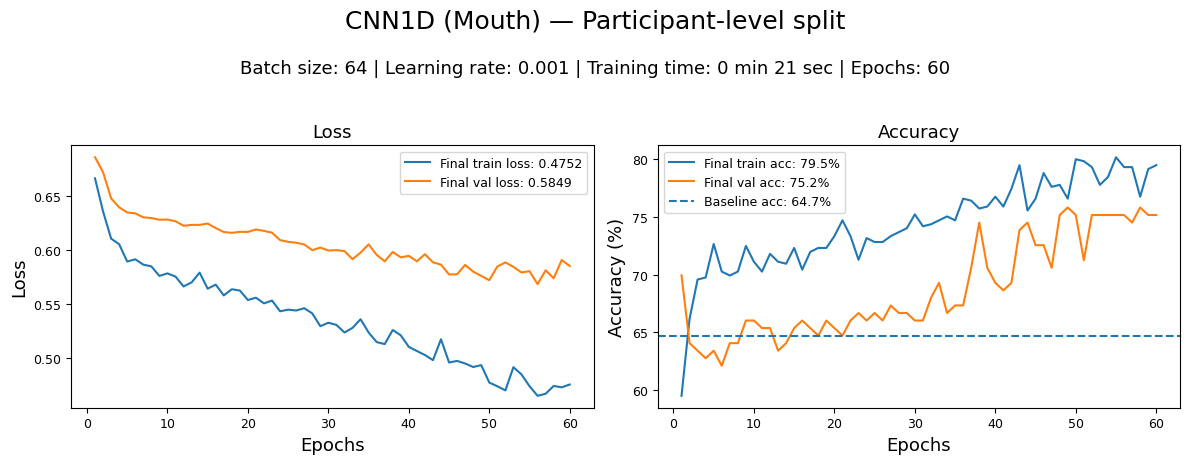

In [18]:
train_loader, val_loader, test_loader, meta = prepare_mouth_data_loaders(
    X_mouth, y_mouth,
    batch_size=64,
    seed=42,
    normalize=True,
    return_meta=True
)

X_val_p = meta["X_val_p"]
y_val_p = meta["y_val_p"]





t0 = time.time()
model, trL, vaL, trA, vaA, trP, valP, _ = train_model_with_loaders(
    model,
    train_loader,
    val_loader,
    epochs=60,
    lr=0.001,
    patience=10,
    use_pos_weight=False
)
t1 = time.time()

print("Final train acc:", trA[-1])
print("Final val acc:", vaA[-1])

# baseline: majority-class accuracy on validation participants
baseline_acc = max(np.mean(y_val_p == 0), np.mean(y_val_p == 1))

training_curve_plot(
    title="CNN1D (Mouth) — Participant-level split",
    train_losses=trL,
    val_losses=vaL,
    train_accs=trA,
    val_accs=vaA,
    batch_size=64,
    learning_rate=0.001,
    training_time=(t1 - t0),
    baseline_acc=baseline_acc
)

In [19]:
train_p = trP[-1].cpu().numpy()  
print(train_p)
val_p   = valP[-1].cpu().numpy()
print(val_p)

[0.2670308  0.3072299  0.29563287 0.15041898 0.5512994  0.8666432
 0.15993811 0.47847393 0.7471647  0.26997742 0.9718741  0.11559094
 0.37034515 0.26803076 0.32403174 0.21292673 0.39991143 0.24838766
 0.85506517 0.15296341 0.68532974 0.35508946 0.36514983 0.48167118
 0.17406207 0.41940996 0.60531944 0.40720868 0.2769581  0.6749998
 0.85322016 0.2760487  0.07623262 0.36168405 0.22902949 0.48079285
 0.34804025 0.17782368 0.04866629 0.75852066 0.10896075 0.39257497
 0.05348235 0.33303225 0.702678   0.9635154  0.617956   0.05442519
 0.9251214  0.551676   0.09601755 0.94523543 0.6582885  0.1721702
 0.03703839 0.46157536 0.61050576 0.19254456 0.45417827 0.08052464
 0.33353117 0.24197385 0.2818348  0.62869364 0.11456887 0.79397154
 0.08048571 0.25668103 0.81925905 0.6926251  0.21950097 0.8903469
 0.42069036 0.835437   0.088611   0.5866559  0.19264942 0.51045495
 0.09658128 0.37418053 0.47262394 0.38300747 0.0365469  0.32821092
 0.09888267 0.10389906 0.371853   0.79499286 0.26358274 0.6103577


In [20]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score


device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

y_prop , y_true, y_pred, y_test = [], [], [], []

with torch.no_grad():
    for xb, yb in test_loader:   # use your test_loader #TODO: CONVERT THIS TO A FUNCTION this in with train and val loaders 
        xb = xb.to(device)

        logits = model(xb)
        probs = torch.sigmoid(logits).cpu().numpy()

        preds = (probs >= 0.5).astype(int)
        y_prop.append(probs)
        y_pred.append(preds)
        y_true.append(yb.numpy().astype(int))

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)
y_prop= np.concatenate(y_prop)


print("TEST accuracy (window-level):", accuracy_score(y_true, y_pred))

# y true from train

TEST accuracy (window-level): 0.6402116402116402


In [21]:
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, average_precision_score

print(f"Accuracy:           {accuracy_score(y_true, y_pred):.4f}")
print(f"Balanced acc:       {balanced_accuracy_score(y_true, y_pred):.4f}")
print(f"F1 (positive):      {f1_score(y_true, y_pred):.4f}")
print(f"ROC AUC:            {roc_auc_score(y_true, y_prop):.4f}")
print(f"Average Precision:  {average_precision_score(y_true, y_prop):.4f}")
print("\nCM:\n", confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=4))

Accuracy:           0.6402
Balanced acc:       0.6026
F1 (positive):      0.4848
ROC AUC:            0.7272
Average Precision:  0.5754

CM:
 [[89 28]
 [40 32]]
              precision    recall  f1-score   support

           0     0.6899    0.7607    0.7236       117
           1     0.5333    0.4444    0.4848        72

    accuracy                         0.6402       189
   macro avg     0.6116    0.6026    0.6042       189
weighted avg     0.6303    0.6402    0.6326       189



In [22]:
baseline = max(np.mean(y_val_p == 0), np.mean(y_val_p == 1))
print("Participant baseline:", baseline)


Participant baseline: 0.6470588235294118



    The CNN is trained on window-level inputs (shape: W x C x L),
    where each participant consists of 9 windows .
    However, labels are defined at the participant level.

    For each participant:
        1. All windows are passed through the model.
        2. Window-level logits are converted to probabilities using sigmoid.
        3. The probabilities are averaged across windows to obtain
           one probability per participant.
        4. A threshold of 0.5 is applied to obtain the predicted class.

In [23]:
def participant_accuracy(model, X_val_p, y_val_p):
    device = next(model.parameters()).device
    model.eval()
    probs = []
    with torch.no_grad():
        for p in range(X_val_p.shape[0]):
            xb = torch.tensor(X_val_p[p], dtype=torch.float32).to(device)  # (9,4,2048)
            logits = model(xb).view(-1)                                     # (9,)
            pr = torch.sigmoid(logits).mean().item()                        # average over 9 windows
            probs.append(pr)
    preds = (np.array(probs) >= 0.5).astype(int)
    return (preds == y_val_p.astype(int)).mean()

print("Participant-level val acc:", participant_accuracy(model, X_val_p, y_val_p))
print("Participant-level test acc:",participant_accuracy(model, X_test_p, y_test_p))

Participant-level val acc: 0.7647058823529411
Participant-level test acc: 0.8095238095238095


In [24]:
print("Total participants:", X_mouth.shape[0])
print("Train participants:", X_train_p.shape[0])
print("Val participants:", X_val_p.shape[0])
print("Test participants:", X_test_p.shape[0])


Total participants: 103
Train participants: 65
Val participants: 17
Test participants: 21


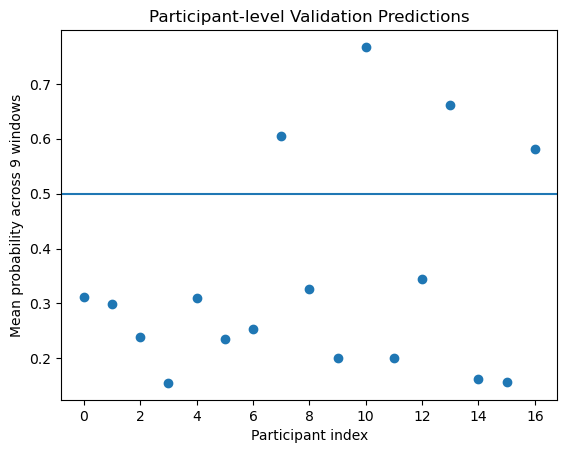

In [25]:
probs = []

model.eval()
with torch.no_grad():
    for p in range(X_val_p.shape[0]): # about 17 idividual
        xb = torch.tensor(X_val_p[p], dtype=torch.float32).to(device)
        logits = model(xb).view(-1)
        pr = torch.sigmoid(logits).mean().item()
        probs.append(pr)

probs = np.array(probs)


plt.figure()
plt.scatter(range(len(probs)), probs)
plt.axhline(0.5)
plt.xlabel("Participant index")
plt.ylabel("Mean probability across 9 windows")
plt.title("Participant-level Validation Predictions")
plt.show()


In [26]:
ages = df_mouth['Age']
print("Age min:", ages.min())
print("Age max:", ages.max())
print("Age std:", ages.std())
# Question, will this work if we have since we have big age cluster around 25-30 

Age min: 18
Age max: 42
Age std: 5.767217990545044


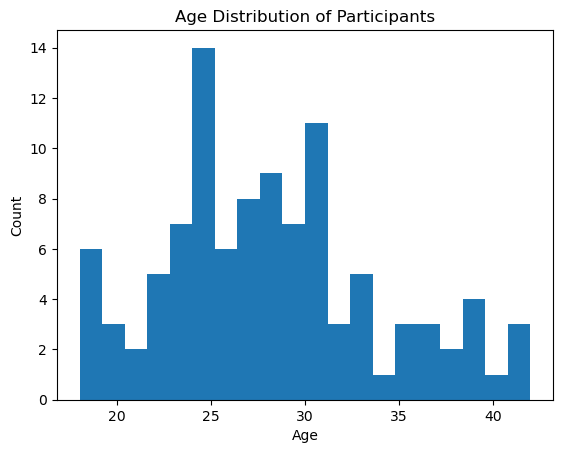

In [27]:
ages = np.array(ages)

plt.figure()
plt.hist(ages, bins=20)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution of Participants")
plt.show()